<a href="https://colab.research.google.com/github/LordSurov/123/blob/main/Lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
Variant<-14
group <-84
set.seed(Variant+2026+group+24656)
c(sample(1:6,1),sample(1:5,1),sample(1:5,1))


[1] 3 3 3

**Задание 3.**

Даны две выборки интервалов времени между событиями (в условных единицах):

Выборка A:

1.2, 0.8, 1.5, 0.9, 1.1, 1.3, 0.7, 1.4, 0.6, 1.0,
1.2, 0.9, 1.3, 1.1, 0.8, 1.5, 0.7, 1.2, 1.4, 0.9

Выборка B:

0.3, 2.1, 0.4, 2.5, 0.2, 2.8, 0.5, 2.3, 0.6, 1.9,
0.4, 2.4, 0.3, 2.7, 0.5, 2.2, 0.4, 2.6, 0.3, 2.9


Для каждой выборки оценить интенсивность потока $\lambda$.

Вычислить коэффициент вариации $k_v$ для обеих выборок. Выдвинуть гипотезу $H_0$: поток простейший (интервалы распределены экспоненциально, $k_v = 1$).

На уровне значимости $\alpha = 0.05$ определить, для какой выборки гипотеза о простейшем потоке отвергается.

Для выборки, где $H_0$ отвергается, подобрать распределение Эрланга. Визуализировать полученные результаты.

In [ ]:
# --- Данные ---
sample_A <- c(1.2, 0.8, 1.5, 0.9, 1.1, 1.3, 0.7, 1.4, 0.6, 1.0,
              1.2, 0.9, 1.3, 1.1, 0.8, 1.5, 0.7, 1.2, 1.4, 0.9)

sample_B <- c(0.3, 2.1, 0.4, 2.5, 0.2, 2.8, 0.5, 2.3, 0.6, 1.9,
              0.4, 2.4, 0.3, 2.7, 0.5, 2.2, 0.4, 2.6, 0.3, 2.9)

cat("Выборка A:", sample_A, "\n")
cat("Выборка B:", sample_B, "\n")


Выборка A: 1.2 0.8 1.5 0.9 1.1 1.3 0.7 1.4 0.6 1 1.2 0.9 1.3 1.1 0.8 1.5 0.7 1.2 1.4 0.9 
Выборка B: 0.3 2.1 0.4 2.5 0.2 2.8 0.5 2.3 0.6 1.9 0.4 2.4 0.3 2.7 0.5 2.2 0.4 2.6 0.3 2.9 


In [ ]:
# --- Оценка интенсивности потока λ
lambda_A <- 1 / mean(sample_A)
lambda_B <- 1 / mean(sample_B)

cat(sprintf("=== Интенсивности потоков ===\n"))
cat(sprintf("Выборка A: среднее = %.4f, λ_A = %.4f\n", mean(sample_A), lambda_A))
cat(sprintf("Выборка B: среднее = %.4f, λ_B = %.4f\n", mean(sample_B), lambda_B))


=== Интенсивности потоков ===
Выборка A: среднее = 1.0750, λ_A = 0.9302
Выборка B: среднее = 1.4150, λ_B = 0.7067


In [ ]:
kv_A <- sd(sample_A) / mean(sample_A)
kv_B <- sd(sample_B) / mean(sample_B)

cat(sprintf("=== Коэффициенты вариации ===\n"))
cat(sprintf("kv_A = %.4f (sd=%.4f, mean=%.4f)\n", kv_A, sd(sample_A), mean(sample_A)))
cat(sprintf("kv_B = %.4f (sd=%.4f, mean=%.4f)\n", kv_B, sd(sample_B), mean(sample_B)))
cat(sprintf("\nДля простейшего потока ожидается kv = 1\n"))
cat(sprintf("kv_A отклонение от 1: %.4f\n", abs(kv_A - 1)))
cat(sprintf("kv_B отклонение от 1: %.4f\n", abs(kv_B - 1)))


=== Коэффициенты вариации ===
kv_A = 0.2594 (sd=0.2789, mean=1.0750)
kv_B = 0.7616 (sd=1.0777, mean=1.4150)

Для простейшего потока ожидается kv = 1
kv_A отклонение от 1: 0.7406
kv_B отклонение от 1: 0.2384


In [ ]:
# --- Проверка гипотезы H0: экспоненциальное распределение ---
# Используем критерий Колмогорова-Смирнова

ks_A <- ks.test(sample_A, "pexp", rate = lambda_A)
ks_B <- ks.test(sample_B, "pexp", rate = lambda_B)

alpha <- 0.05

cat("=== Проверка гипотезы H0 (критерий Колмогорова-Смирнова) ===\n")
cat(sprintf("Уровень значимости α = %.2f\n\n", alpha))

cat(sprintf("Выборка A:\n"))
cat(sprintf("  Статистика D = %.4f, p-value = %.4f\n", ks_A$statistic, ks_A$p.value))
cat(sprintf("  H0 %s (p-value %s α)\n\n",
            ifelse(ks_A$p.value < alpha, "ОТВЕРГАЕТСЯ", "не отвергается"),
            ifelse(ks_A$p.value < alpha, "<", ">=")))

cat(sprintf("Выборка B:\n"))
cat(sprintf("  Статистика D = %.4f, p-value = %.4f\n", ks_B$statistic, ks_B$p.value))
cat(sprintf("  H0 %s (p-value %s α)\n\n",
            ifelse(ks_B$p.value < alpha, "ОТВЕРГАЕТСЯ", "не отвергается"),
            ifelse(ks_B$p.value < alpha, "<", ">=")))


Warning message in ks.test.default(sample_A, "pexp", rate = lambda_A):
“ties should not be present for the one-sample Kolmogorov-Smirnov test”
Warning message in ks.test.default(sample_B, "pexp", rate = lambda_B):
“ties should not be present for the one-sample Kolmogorov-Smirnov test”


=== Проверка гипотезы H0 (критерий Колмогорова-Смирнова) ===
Уровень значимости α = 0.05

Выборка A:
  Статистика D = 0.4286, p-value = 0.0013
  H0 ОТВЕРГАЕТСЯ (p-value < α)

Выборка B:
  Статистика D = 0.2389, p-value = 0.2039
  H0 не отвергается (p-value >= α)



In [ ]:
# --- Подбор распределения Эрланга для выборки B ---
k_erlang  <- round(1 / kv_B^2)
mu_erlang <- k_erlang / mean(sample_B)
erlang_label <- paste0("Эрланг(k=", k_erlang, ")")

cat("=== Подбор распределения Эрланга для выборки B ===\n")
cat(sprintf("kv_B^2 = %.4f  =>  k = %.4f => %d\n", kv_B^2, 1/kv_B^2, k_erlang))
cat(sprintf("Параметры: k = %d, mu = %.4f\n", k_erlang, mu_erlang))
cat(sprintf("Теор. среднее  = k/mu = %.4f  (выборочное: %.4f)\n",
            k_erlang / mu_erlang, mean(sample_B)))
cat(sprintf("Теор. дисперсия = k/mu^2 = %.4f  (выборочная: %.4f)\n",
            k_erlang / mu_erlang^2, var(sample_B)))

ks_B_erlang <- ks.test(sample_B, "pgamma",
                        shape = k_erlang, rate = mu_erlang)
cat(sprintf("\nKS-тест (Эрланг): D = %.4f, p-value = %.4f\n",
            ks_B_erlang$statistic, ks_B_erlang$p.value))
cat(sprintf("H0 (Эрланг) %s\n",
            ifelse(ks_B_erlang$p.value < alpha, "ОТВЕРГАЕТСЯ", "не отвергается")))


=== Подбор распределения Эрланга для выборки B ===
kv_B^2 = 0.5800  =>  k = 1.7241 => 2
Параметры: k = 2, mu = 1.4134
Теор. среднее  = k/mu = 1.4150  (выборочное: 1.4150)
Теор. дисперсия = k/mu^2 = 1.0011  (выборочная: 1.1613)


Warning message in ks.test.default(sample_B, "pgamma", shape = k_erlang, rate = mu_erlang):
“ties should not be present for the one-sample Kolmogorov-Smirnov test”



KS-тест (Эрланг): D = 0.2919, p-value = 0.0663
H0 (Эрланг) не отвергается


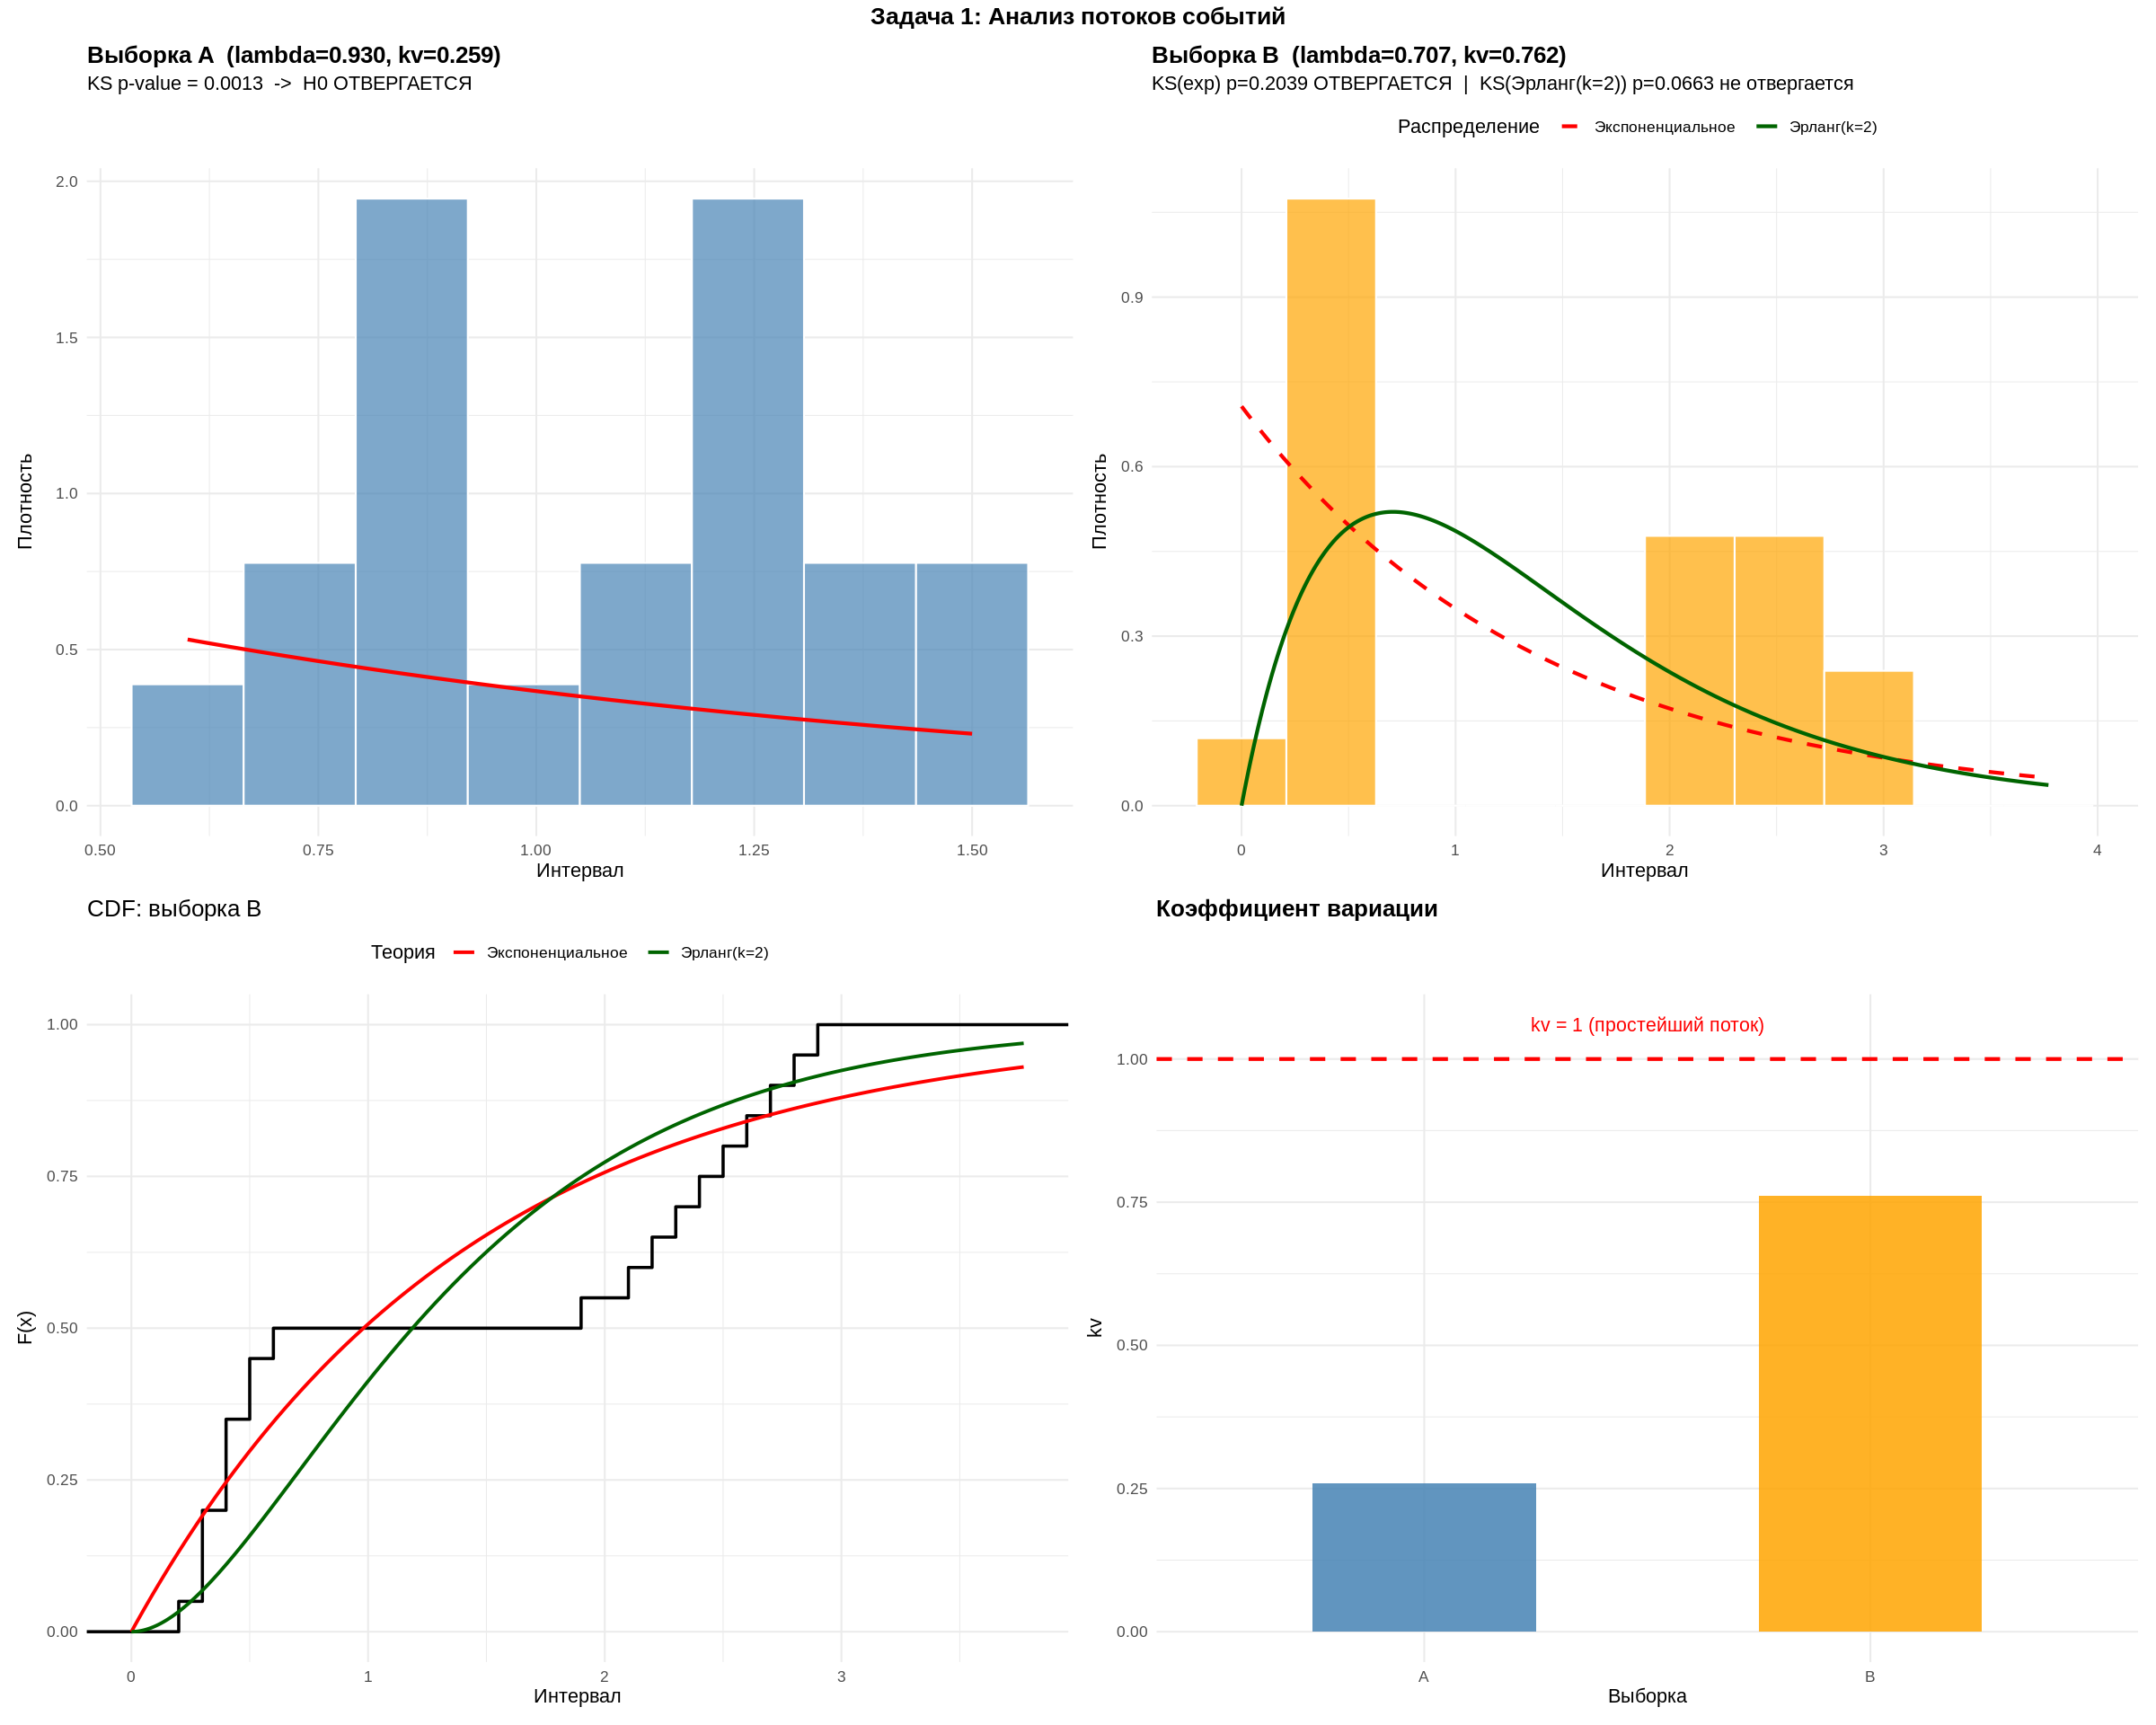

In [ ]:
library(ggplot2)

if (!requireNamespace("patchwork", quietly = TRUE)) {
  install.packages("patchwork")
}
library(patchwork)

x_max_B <- max(sample_B) * 1.3
x_seq_B <- seq(0, x_max_B, length.out = 500)

p1 <- ggplot(data.frame(x = sample_A), aes(x = x)) +
  geom_histogram(aes(y = after_stat(density)),
                 bins = 8, fill = "steelblue",
                 color = "white", alpha = 0.7) +
  stat_function(fun  = dexp,
                args = list(rate = lambda_A),
                color = "red", linewidth = 1.2) +
  labs(title    = sprintf("Выборка A  (lambda=%.3f, kv=%.3f)",
                          lambda_A, kv_A),
       subtitle = sprintf("KS p-value = %.4f  ->  H0 %s",
                          ks_A$p.value,
                          ifelse(ks_A$p.value < alpha,
                                 "ОТВЕРГАЕТСЯ", "не отвергается")),
       x = "Интервал", y = "Плотность") +
  theme_minimal(base_size = 13) +
  theme(plot.title = element_text(face = "bold"))

df_theory_B <- data.frame(
  x    = rep(x_seq_B, 2),
  y    = c(dexp(x_seq_B, rate = lambda_B),
           dgamma(x_seq_B, shape = k_erlang, rate = mu_erlang)),
  dist = rep(c("Экспоненциальное", erlang_label),
             each = length(x_seq_B))
)

color_vals    <- c("red", "darkgreen")
linetype_vals <- c("dashed", "solid")
names(color_vals)    <- c("Экспоненциальное", erlang_label)
names(linetype_vals) <- c("Экспоненциальное", erlang_label)

p2 <- ggplot(data.frame(x = sample_B), aes(x = x)) +
  geom_histogram(aes(y = after_stat(density)),
                 bins = 10, fill = "orange",
                 color = "white", alpha = 0.7) +
  geom_line(data = df_theory_B,
            aes(x = x, y = y,
                color    = dist,
                linetype = dist),
            linewidth = 1.2) +
  scale_color_manual(name   = "Распределение",
                     values = color_vals) +
  scale_linetype_manual(name   = "Распределение",
                        values = linetype_vals) +
  labs(title    = sprintf("Выборка B  (lambda=%.3f, kv=%.3f)",
                          lambda_B, kv_B),
       subtitle = sprintf("KS(exp) p=%.4f ОТВЕРГАЕТСЯ  |  KS(%s) p=%.4f %s",
                          ks_B$p.value,
                          erlang_label,
                          ks_B_erlang$p.value,
                          ifelse(ks_B_erlang$p.value < alpha,
                                 "ОТВЕРГАЕТСЯ", "не отвергается")),
       x = "Интервал", y = "Плотность") +
  theme_minimal(base_size = 13) +
  theme(plot.title      = element_text(face = "bold"),
        legend.position = "top")

cdf_df <- data.frame(
  x    = rep(x_seq_B, 2),
  y    = c(pexp(x_seq_B, rate = lambda_B),
           pgamma(x_seq_B, shape = k_erlang, rate = mu_erlang)),
  dist = rep(c("Экспоненциальное", erlang_label),
             each = length(x_seq_B))
)

p3 <- ggplot(data.frame(x = sample_B), aes(x = x)) +
  stat_ecdf(geom = "step", color = "black", linewidth = 1.0) +
  geom_line(data = cdf_df,
            aes(x = x, y = y, color = dist),
            linewidth = 1.1) +
  scale_color_manual(name   = "Теория",
                     values = color_vals) +
  labs(title = "CDF: выборка B",
       x = "Интервал", y = "F(x)") +
  theme_minimal(base_size = 13) +
  theme(legend.position = "top")

kv_df <- data.frame(
  Выборка = c("A", "B"),
  kv      = c(kv_A, kv_B)
)

p4 <- ggplot(kv_df, aes(x = Выборка, y = kv, fill = Выборка)) +
  geom_col(width = 0.5, alpha = 0.85) +
  geom_hline(yintercept = 1,
             color = "red", linewidth = 1.2, linetype = "dashed") +
  annotate("text", x = 1.5, y = 1.06,
           label = "kv = 1 (простейший поток)",
           color = "red", size = 4.5) +
  scale_fill_manual(values = c("A" = "steelblue", "B" = "orange")) +
  labs(title = "Коэффициент вариации", y = "kv", x = "Выборка") +
  theme_minimal(base_size = 13) +
  theme(legend.position = "none",
        plot.title = element_text(face = "bold"))

(p1 | p2) / (p3 | p4) +
  plot_annotation(title = "Задача 1: Анализ потоков событий",
                  theme = theme(plot.title = element_text(
                    size = 16, face = "bold", hjust = 0.5)))


**Задача 3**

Независимые нормально распределенные величины:

$X \sim N(5, 2)$ (матожидание 5, дисперсия 2)

$Y \sim N(3, 1)$ (матожидание 3, дисперсия 1)

Найти распределение $Z = X + Y$, его плотность, математическое ожидание и дисперсию (теоретически, экспериментально.



In [ ]:
# Теоретический результат
# X ~ N(mu_X, sigma2_X),  Y ~ N(mu_Y, sigma2_Y)
# Z = X + Y ~ N(mu_X + mu_Y,  sigma2_X + sigma2_Y)

mu_X    <- 5;  sigma2_X <- 2
mu_Y    <- 3;  sigma2_Y <- 1

mu_Z_theory    <- mu_X + mu_Y
sigma2_Z_theory <- sigma2_X + sigma2_Y
sigma_Z_theory  <- sqrt(sigma2_Z_theory)

cat("=== Теоретический результат ===\n")
cat(sprintf("X ~ N(%g, %g)  =>  E[X]=%g, Var(X)=%g\n", mu_X, sigma2_X, mu_X, sigma2_X))
cat(sprintf("Y ~ N(%g, %g)  =>  E[Y]=%g, Var(Y)=%g\n", mu_Y, sigma2_Y, mu_Y, sigma2_Y))
cat(sprintf("\nZ = X + Y ~ N(%g, %g)\n", mu_Z_theory, sigma2_Z_theory))
cat(sprintf("E[Z]   = E[X] + E[Y]       = %g + %g = %g\n", mu_X, mu_Y, mu_Z_theory))
cat(sprintf("Var(Z) = Var(X) + Var(Y)   = %g + %g = %g\n", sigma2_X, sigma2_Y, sigma2_Z_theory))
cat(sprintf("σ(Z)   = sqrt(Var(Z))      = %.4f\n", sigma_Z_theory))


=== Теоретический результат ===
X ~ N(5, 2)  =>  E[X]=5, Var(X)=2
Y ~ N(3, 1)  =>  E[Y]=3, Var(Y)=1

Z = X + Y ~ N(8, 3)
E[Z]   = E[X] + E[Y]       = 5 + 3 = 8
Var(Z) = Var(X) + Var(Y)   = 2 + 1 = 3
σ(Z)   = sqrt(Var(Z))      = 1.7321


In [ ]:
# Экспериментальная проверка
set.seed(42)
N <- 100000

X_sim <- rnorm(N, mean = mu_X, sd = sqrt(sigma2_X))
Y_sim <- rnorm(N, mean = mu_Y, sd = sqrt(sigma2_Y))
Z_sim <- X_sim + Y_sim

mu_Z_sim    <- mean(Z_sim)
sigma2_Z_sim <- var(Z_sim)
sigma_Z_sim  <- sd(Z_sim)

cat("=== Экспериментальный результат (N =", N, ") ===\n")
cat(sprintf("E[Z]   выборочное = %.6f  (теория: %g)\n",    mu_Z_sim,    mu_Z_theory))
cat(sprintf("Var(Z) выборочная = %.6f  (теория: %g)\n",  sigma2_Z_sim, sigma2_Z_theory))
cat(sprintf("σ(Z)   выборочная = %.6f  (теория: %.4f)\n", sigma_Z_sim,  sigma_Z_theory))


=== Экспериментальный результат (N = 1e+05 ) ===
E[Z]   выборочное = 7.992674  (теория: 8)
Var(Z) выборочная = 3.009384  (теория: 3)
σ(Z)   выборочная = 1.734758  (теория: 1.7321)


**Задание 3**

Пакет данных передается по каналу связи, состоящему из $K$ последовательно включенных линий ($K=3$). Время передачи пакета по каждой линии распределено экспоненциально со средним значением $T_i$:

Линия 1: $T_1 = 10$ мс ($\lambda_1 = 0.1$).

Линия 2: $T_2 = 20$ мс ($\lambda_2 = 0.05$).

Линия 3: $T_3 = 5$ мс ($\lambda_3 = 0.2$).

Найти преобразование Лапласа-Стилтьеса (ПЛС) распределения времени передачи пакета через весь канал, а также его математическое ожидание и дисперсию. Построить имитационную модель процесса передачи и сравнить теоретические результаты с выборочными характеристиками.

In [ ]:
K <- 3
T_avg <- c(10, 20, 5)
lam   <- 1 / T_avg

cat("=== Параметры канала ===\n")
for (i in seq_len(K)) {
  cat(sprintf("Линия %d: T_%d = %g мс,  lambda_%d = %.4f\n",
              i, i, T_avg[i], i, lam[i]))
}


=== Параметры канала ===
Линия 1: T_1 = 10 мс,  lambda_1 = 0.1000
Линия 2: T_2 = 20 мс,  lambda_2 = 0.0500
Линия 3: T_3 = 5 мс,  lambda_3 = 0.2000


In [ ]:
# --- Теоретический анализ ---
E_T_theory   <- sum(T_avg)
Var_T_theory <- sum(T_avg^2)
Std_T_theory <- sqrt(Var_T_theory)

cat("=== Теоретические характеристики ===\n")
cat(sprintf("E[T]   = sum(T_i) = %g + %g + %g = %g мс\n",
            T_avg[1], T_avg[2], T_avg[3], E_T_theory))
cat(sprintf("Var(T) = sum(T_i^2) = %g + %g + %g = %g мс^2\n",
            T_avg[1]^2, T_avg[2]^2, T_avg[3]^2, Var_T_theory))
cat(sprintf("sigma(T) = sqrt(Var(T)) = %.4f мс\n", Std_T_theory))


=== Теоретические характеристики ===
E[T]   = sum(T_i) = 10 + 20 + 5 = 35 мс
Var(T) = sum(T_i^2) = 100 + 400 + 25 = 525 мс^2
sigma(T) = sqrt(Var(T)) = 22.9129 мс


In [ ]:
LST_func <- function(s) {
  prod(lam / (lam + s))
}

h <- 1e-7

E_T_LST   <- -(LST_func(h) - LST_func(0)) / h

L_2h <- LST_func(2 * h)
L_1h <- LST_func(h)
L_0  <- LST_func(0)
E_T2_LST  <- (L_2h - 2 * L_1h + L_0) / h^2
Var_T_LST <- E_T2_LST - E_T_LST^2

cat("=== Характеристики через ПЛС (численное дифференцирование) ===\n")
cat(sprintf("L(0)   = %.6f  (должно быть 1)\n", L_0))
cat(sprintf("E[T]   = %.6f мс  (теория: %g)\n", E_T_LST,   E_T_theory))
cat(sprintf("Var(T) = %.6f мс^2  (теория: %g)\n", Var_T_LST, Var_T_theory))
cat(sprintf("\nФормула ПЛС:\n"))
cat(sprintf("L(s) = (%.3f/(%.3f+s)) x (%.3f/(%.3f+s)) x (%.3f/(%.3f+s))\n",
            lam[1], lam[1], lam[2], lam[2], lam[3], lam[3]))


=== Характеристики через ПЛС (численное дифференцирование) ===
L(0)   = 1.000000  (должно быть 1)
E[T]   = 34.999913 мс  (теория: 35)
Var(T) = 525.017372 мс^2  (теория: 525)

Формула ПЛС:
L(s) = (0.100/(0.100+s)) x (0.050/(0.050+s)) x (0.200/(0.200+s))


In [ ]:
# --- Имитационная модель ---
set.seed(123)
N_sim <- 200000

# Время передачи через каждую линию
sim_lines   <- sapply(seq_len(K), function(i) rexp(N_sim, rate = lam[i]))
T_total_sim <- rowSums(sim_lines)

E_T_sim   <- mean(T_total_sim)
Var_T_sim <- var(T_total_sim)
Std_T_sim <- sd(T_total_sim)

cat("=== Имитационная модель (N =", N_sim, ") ===\n")
cat(sprintf("E[T]     выборочное = %.6f мс   (теория: %g)\n",  E_T_sim,   E_T_theory))
cat(sprintf("Var(T)   выборочная = %.6f мс^2 (теория: %g)\n", Var_T_sim, Var_T_theory))
cat(sprintf("sigma(T) выборочная = %.6f мс   (теория: %.4f)\n", Std_T_sim, Std_T_theory))


=== Имитационная модель (N = 2e+05 ) ===
E[T]     выборочное = 34.998305 мс   (теория: 35)
Var(T)   выборочная = 523.079881 мс^2 (теория: 525)
sigma(T) выборочная = 22.870940 мс   (теория: 22.9129)
